## PARAMETER ESTIMATION NOTEBOOK (Gravity Compensation)

In [2]:
# =========================================================================================================================== Import
import time
import os
import shutil

%matplotlib ipympl
from matplotlib import pyplot as plt
from scipy.linalg import solve_continuous_lyapunov, block_diag

import rosbag2_py
from rclpy.serialization import serialize_message, deserialize_message
from sensor_msgs.msg import JointState
import casadi

import numpy as np
from tqdm import tqdm

import pandas as pd

from scipy.signal import butter, filtfilt, savgol_filter

import sys
build_path = "./ahand_finger_generatedFiles_py/build"
if os.path.exists(build_path):
    sys.path.append(os.path.abspath(build_path))
else:
    print(f"Warning: path '{build_path}' does not exist.")

from thunder_ahand_finger_py import thunder_ahand_finger

MESH_DIR = './description/urdf/meshes/'
URDF_PATH = './description/urdf/allegro_hand_description_right_B.urdf'
XML_PATH = './description/urdf/allegro_hand_description_right_B.xml'
CSV_PATH = '/home/leo/Desktop/allegro_hand_ros2_ws/workdir/allegro_log.csv'
JOINT_NAMES = ['joint_4_0', 'joint_5_0', 'joint_6_0', 'joint_7_0']
SAVE_FILENAME = '/home/leo/Desktop/ahand_dynamic_friction.txt'

MASSES_URDF = [0.0176, 0.086, 0.0367, 0.0057] # [Kg]
INERTIAS_URDF = [[1.32064e-05, 1.22498e-05, 2.64678e-06],
                 [5.66968e-05, 4.87935e-05, 1.75097e-05],
                 [1.45504e-05, 1.30076e-05, 3.70193e-06],
                 [5.27679e-06, 4.04675e-06, 2.638e-06]] # [Kg m^2]

np.random.seed(41)


In [3]:
# =========================================================================================================================== Define Function
# Bag Read/Write
def read_bag(file_path, topic_name = '/allegroHand_0/joint_states', store=False, path_out=None):
    first = True
    # Open the bag reader
    reader = rosbag2_py.SequentialReader()

    # set options and open the bag
    storage_options = rosbag2_py.StorageOptions(uri=file_path)
    converter_options = rosbag2_py.ConverterOptions('', '')
    reader.open(storage_options, converter_options)

    dataset = []
    header = []
    # scroll the bag
    while reader.has_next():
        (topic, data, t) = reader.read_next()
        if topic == topic_name:
        #if topic == '/allegroHand_0/torque_cmd':
            msg = deserialize_message(data, JointState)
            joint_names = msg.name

            # select specific joints
            indices = [joint_names.index(name) for name in JOINT_NAMES if name in joint_names]
            selected_joint_names = [joint_names[i] for i in indices]
            if first:
                joint_names = msg.name
                # get header
                pos_header    = [f"pos_{name}" for name in selected_joint_names]
                effort_header = [f"eff_{name}" for name in selected_joint_names]
                vel_header    = [f"vel_{name}" for name in selected_joint_names]
                #acc_header    = [f"acc_{name}" for name in selected_joint_names]
                #header = ['t'] + pos_header + vel_header + acc_header + effort_header
                header = ['t'] + pos_header + effort_header + vel_header
                first = False
            elif joint_names != msg.name:
                raise ValueError("Joint names do not match")

            # Store data
            selected_positions = [msg.position[i] for i in indices]
            selected_velocities = [msg.velocity[i] for i in indices]
            selected_effort = [msg.effort[i] for i in indices]
            row = [t/1e9] + selected_positions + selected_effort + selected_velocities
            dataset.append(row)

    # store in dataframe
    df = pd.DataFrame(dataset, columns=header)
    if store:
        df.to_csv(file_path, index=False)

    return df
def read_csv(file_path, joint_names = None, store=False, path_out=None):
    # Read the CSV
    df_raw = pd.read_csv(file_path)

    # Infer joint names if not provided
    if joint_names is None:
        joint_names = sorted(set(
            c.replace('_pos', '').replace('_vel', '').replace('_effort', '')
            for c in df_raw.columns if any(x in c for x in ['_pos', '_vel', '_effort'])
        ))

    # Input column names (from CSV)
    pos_in = [f"{j}_pos" for j in joint_names]
    eff_in = [f"{j}_effort" for j in joint_names]
    vel_in = [f"{j}_vel" for j in joint_names]

    # Output column names (desired format)
    pos_out = [f"pos_{j}" for j in joint_names]
    eff_out = [f"eff_{j}" for j in joint_names]
    vel_out = [f"vel_{j}" for j in joint_names]

    # Build final DataFrame with renamed columns
    df = pd.DataFrame()
    df['t'] = range(len(df_raw))  # add time index
    for in_cols, out_cols in zip([pos_in, eff_in, vel_in], [pos_out, eff_out, vel_out]):
        for ci, co in zip(in_cols, out_cols):
            if ci in df_raw.columns:
                df[co] = df_raw[ci]
            else:
                df[co] = None  # if missing, fill with NaN

    # Optionally store
    if store:
        out_path = path_out or file_path.replace('.csv', '_parsed.csv')
        df.to_csv(out_path, index=False)

    return df

def write_filtered_bag(file_path, t_log, q_log, tau_log, joint_names_filtered):
    if os.path.exists(file_path):
        print(f"Overwriting existing bag: {file_path}")
        shutil.rmtree(file_path)
    all_joint_names = [f'joint_{i}_0' for i in range(15)]
    # Create writer
    writer = rosbag2_py.SequentialWriter()
    storage_options = rosbag2_py.StorageOptions(uri=file_path, storage_id='sqlite3')
    converter_options = rosbag2_py.ConverterOptions('', '')
    writer.open(storage_options, converter_options)

    # Create topic metadata
    topic_name = '/allegroHand_0/torque_cmd'
    topic_type = 'sensor_msgs/msg/JointState'
    writer.create_topic(rosbag2_py.TopicMetadata(name=topic_name,
                                                 type=topic_type,
                                                 serialization_format='cdr'))

    # Map filtered indices to full joint list
    idx_map = [all_joint_names.index(j) if j in all_joint_names else None for j in joint_names_filtered]

    # Write data
    for i in range(len(t_log)):
        msg = JointState()
        msg.header.stamp.sec = int(t_log[i])
        msg.header.stamp.nanosec = int((t_log[i] - int(t_log[i])) * 1e9)
        msg.name = all_joint_names
        # Initialize all zeros
        q_full = np.zeros(15)
        tau_full = np.zeros(15)
        # Fill available joints
        for j, idx in enumerate(idx_map):
            if idx is not None:
                q_full[idx] = q_log[i, j]
                tau_full[idx] = tau_log[i, j]

        msg.position = q_full.tolist()
        msg.effort = tau_full.tolist()
        writer.write(topic_name, serialize_message(msg), int(t_log[i]*1e9))

    print(f"Filtered bag written to {file_path} with all joints 0-14")


# Matrix Eigenvalues
def powerm(v, A, niter): #POWER ITERATION METHOD
    for i in range(niter):
        v = A @ v
        v = v/casadi.norm_2(v)
    l = v.T@A@v
    return v, l
def def_powerm(a, niter=None): #DEFLATION VERSION OF PIM FOR 3X3 MATRIX ---> CALCULATE ALL EIGENVALUES FROM GREATER TO SMALLER
    #AND THEIR EIGENVECTORS
    v0 = casadi.DM([1,1,1])

    if niter is None:
        niter = 40

    v1,l1 = powerm(v0, a, niter)

    v0 = casadi.DM([0,1,1])
    a2 = a - l1*(v1 @ v1.T)
    v2, l2 = powerm(v0, a2, niter)

    v0 = casadi.DM([0,0,1])
    a3 = a2 - l2 * (v2 @ v2.T)
    v3, l3 = powerm(v0, a3, niter)


    D = casadi.vertcat(l1,l2,l3)
    V = casadi.horzcat(v1,v2,v3)
    return V, D
sym_matrix = casadi.SX.sym('M', 3, 3)
eigenvalues = casadi.eig_symbolic(sym_matrix)
f_eigen = casadi.Function('eigen', [sym_matrix], [eigenvalues])
_, eigenvalues = def_powerm(sym_matrix)
f_powerm = casadi.Function('powerm', [sym_matrix], [eigenvalues])
#minimum eigenvalue
def minimum(eigen):
    min = 10000000000000
    for i in range(3):
        min = casadi.if_else(eigen[i] <= min, eigen[i], min)

    return min
def SN(eigen):
    p = 3
    l1 = eigen[0]**(-p)
    l2 = eigen[1]**(-p)
    l3 = eigen[2]**(-p)

    min = (l1 + l2 + l3)**(-1/p)


    return min
def det(A):
    if np.isscalar(A):
        return A
    elif A.shape[0]==1:
        return A[0,0]
    elif A.shape[0]==2:
        return (A[0,0]*A[1,1] - A[1,0]*A[0,1])
    elif A.shape[0]==3:
        return (A[0, 0]*(A[1, 1]*A[2, 2] - A[1, 2]*A[2, 1])
                - A[0, 1]*(A[1, 0]*A[2, 2] - A[1, 2]*A[2, 0])
                + A[0, 2]*(A[1, 0]*A[2, 1] - A[1, 1]*A[2, 0]))
    else:
        raise NotImplementedError("Supported dimensions: 1x1, 2x2, 3x3")
# Skew-symmetric matrix
def skew(v):
    return np.array([[0, -v[2], v[1]],
                     [v[2], 0, -v[0]],
                     [-v[1], v[0], 0]])
def casadi_skew(v):
    return casadi.vertcat(
        casadi.horzcat(0, -v[2], v[1]),
        casadi.horzcat(v[2], 0, -v[0]),
        casadi.horzcat(-v[1], v[0], 0)
    )

# Dynamic Parameters Store/Load
def save_dynamics(filename, hat_Pi, num_joints):
    par_per_link = int(hat_Pi.shape[0]/num_joints)

    masses = [(hat_Pi[i*par_per_link]).item() for i in range(num_joints)]

    CoMs_x = [(hat_Pi[i*par_per_link+1]/masses[i]).item() for i in range(num_joints)]        #pi = m*cx
    CoMs_y = [(hat_Pi[i*par_per_link+2]/masses[i]).item() for i in range(num_joints)]
    CoMs_z = [(hat_Pi[i*par_per_link+3]/masses[i]).item() for i in range(num_joints)]

    Is_xx = [(hat_Pi[i*par_per_link+4] - (masses[i]*CoMs_y[i]**2 - masses[i]*CoMs_z[i]**2)).item()      for i in range(num_joints)]
    Is_xy = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_y[i])).item()                        for i in range(num_joints)]
    Is_xz = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_z[i])).item()                        for i in range(num_joints)]
    Is_yy = [(hat_Pi[i*par_per_link+7] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_z[i]**2)).item()   for i in range(num_joints)]
    Is_yz = [(hat_Pi[i*par_per_link+8] - (masses[i]*CoMs_y[i]*CoMs_z[i])).item()   for i in range(num_joints)]
    Is_zz = [(hat_Pi[i*par_per_link+9] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_y[i]**2)).item()   for i in range(num_joints)]
    if par_per_link>10:
        Ds = [(hat_Pi[i*par_per_link+10]).item()        for i in range(n)]
        Fs = [(hat_Pi[i*par_per_link+11]).item()        for i in range(n)]

    with open(filename, 'w') as f:
        f.write("=== Dynamic parameters ======\n")
        f.write(f"PI size: {hat_Pi.shape}\n")
        for i in range(num_joints):
            f.write(f"\tlink {i+1}:\n")
            f.write(f"\t\tinertial:\n")
            f.write(f"\t\t\tsymb: [1,1,1,1,1,1,1,1,1,1]\n")
            f.write(f"\t\t\tmass: {masses[i]}\n")
            f.write(f"\t\t\tCoM_x: {CoMs_x[i]}\n")
            f.write(f"\t\t\tCoM_y: {CoMs_y[i]}\n")
            f.write(f"\t\t\tCoM_z: {CoMs_z[i]}\n")
            f.write(f"\t\t\tIxx: {Is_xx[i]}\n")
            f.write(f"\t\t\tIxy: {Is_xy[i]}\n")
            f.write(f"\t\t\tIxz: {Is_xz[i]}\n")
            f.write(f"\t\t\tIyy: {Is_yy[i]}\n")
            f.write(f"\t\t\tIyz: {Is_yz[i]}\n")
            f.write(f"\t\t\tIzz: {Is_zz[i]}\n")
            if par_per_link>10:
                f.write(f"\t\tfriction:\n")
                f.write(f"\t\t\tsymb: [1,1]\n")
                f.write(f"\t\t\tDl: [{Ds[i]},{Fs[i]}]\n")
        f.write("=============================\n")
def load_dynamics(filename, num_joints): # filename -> (hat_Pi, dict)
    dynamics = {}
    hat_Pi = np.zeros(12*num_joints)
    with open(filename, 'r') as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        if line.startswith('mass:'):
            dynamics.setdefault('mass', []).append(float(line.split(':')[1]))
        elif line.startswith('CoM_x:'):
            dynamics.setdefault('CoM_x', []).append(float(line.split(':')[1]))
        elif line.startswith('CoM_y:'):
            dynamics.setdefault('CoM_y', []).append(float(line.split(':')[1]))
        elif line.startswith('CoM_z:'):
            dynamics.setdefault('CoM_z', []).append(float(line.split(':')[1]))
        elif line.startswith('Ixx:'):
            dynamics.setdefault('Ixx', []).append(float(line.split(':')[1]))
        elif line.startswith('Ixy:'):
            dynamics.setdefault('Ixy', []).append(float(line.split(':')[1]))
        elif line.startswith('Ixz:'):
            dynamics.setdefault('Ixz', []).append(float(line.split(':')[1]))
        elif line.startswith('Iyy:'):
            dynamics.setdefault('Iyy', []).append(float(line.split(':')[1]))
        elif line.startswith('Iyz:'):
            dynamics.setdefault('Iyz', []).append(float(line.split(':')[1]))
        elif line.startswith('Izz:'):
            dynamics.setdefault('Izz', []).append(float(line.split(':')[1]))

    # reconstruct hat_Pi
    hat_Pi[0::12] = dynamics['mass']
    hat_Pi[1::12] = dynamics['CoM_x'] * dynamics['mass']
    hat_Pi[2::12] = dynamics['CoM_y'] * dynamics['mass']
    hat_Pi[3::12] = dynamics['CoM_z'] * dynamics['mass']
    hat_Pi[4::12] = dynamics['Ixx'] + dynamics['mass'] * (dynamics['CoM_y']**2 + dynamics['CoM_z']**2)
    hat_Pi[5::12] = dynamics['Ixy'] + dynamics['mass'] * (dynamics['CoM_x'] * dynamics['CoM_y'])
    hat_Pi[6::12] = dynamics['Ixz'] + dynamics['mass'] * (dynamics['CoM_x'] * dynamics['CoM_z'])
    hat_Pi[7::12] = dynamics['Iyy'] + dynamics['mass'] * (dynamics['CoM_x']**2 + dynamics['CoM_z']**2)
    hat_Pi[8::12] = dynamics['Iyz'] + dynamics['mass'] * (dynamics['CoM_y'] * dynamics['CoM_z'])
    hat_Pi[9::12] = dynamics['Izz'] + dynamics['mass'] * (dynamics['CoM_x']**2 + dynamics['CoM_y']**2)


    return hat_Pi, dynamics

def print_result(hat_Pi, par_per_link):
    masses = [(hat_Pi[i*par_per_link]).item() for i in range(n)]

    CoMs_x = [(hat_Pi[i*par_per_link+1]/masses[i]).item() for i in range(n)]        #pi = m*cx
    CoMs_y = [(hat_Pi[i*par_per_link+2]/masses[i]).item() for i in range(n)]
    CoMs_z = [(hat_Pi[i*par_per_link+3]/masses[i]).item() for i in range(n)]

    Is_xx = [(hat_Pi[i*par_per_link+4] - (masses[i]*CoMs_y[i]**2 - masses[i]*CoMs_z[i]**2)).item()        for i in range(n)]
    Is_xy = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_y[i])).item()                          for i in range(n)]
    Is_xz = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_z[i])).item()                          for i in range(n)]
    Is_yy = [(hat_Pi[i*par_per_link+7] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_z[i]**2)).item()        for i in range(n)]
    Is_yz = [(hat_Pi[i*par_per_link+8] - (masses[i]*CoMs_y[i]*CoMs_z[i])).item()                          for i in range(n)]
    Is_zz = [(hat_Pi[i*par_per_link+9] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_y[i]**2)).item()        for i in range(n)]

    if par_per_link>10:
        Ds = [(hat_Pi[i*par_per_link+10]).item()        for i in range(n)]
        Fs = [(hat_Pi[i*par_per_link+11]).item()        for i in range(n)]
    print("=== Dynamic parameters ======")
    print("PI size:", hat_Pi.shape)
    for i in range(thunder_ahand.get_numJoints()):
        print(f"\tlink {i+1}:")
        print(f"\t\tinertial:")
        print(f"\t\t\tsymb: [1,1,1,1,1,1,1,1,1,1]")
        print(f"\t\t\tmass: {masses[i]}")
        print(f"\t\t\tCoM_x: {CoMs_x[i]}")
        print(f"\t\t\tCoM_y: {CoMs_y[i]}")
        print(f"\t\t\tCoM_z: {CoMs_z[i]}")
        print(f"\t\t\tIxx: {Is_xx[i]}")
        print(f"\t\t\tIxy: {Is_xy[i]}")
        print(f"\t\t\tIxz: {Is_xz[i]}")
        print(f"\t\t\tIyy: {Is_yy[i]}")
        print(f"\t\t\tIyz: {Is_yz[i]}")
        print(f"\t\t\tIzz: {Is_zz[i]}")
        if par_per_link>10:
            print(f"\t\tfriction: ")
            print(f"\t\t\tsymb: [1,1]")
            print(f"\t\t\tDl: [{Ds[i]},{Fs[i]}]")
    print("=============================")

Extract Data

In [4]:
# =========================================================================================================================== Start
df = read_csv(CSV_PATH, joint_names=JOINT_NAMES)

In [5]:
# =========================================================================================================================== Process data
t0 = df['t'].to_numpy()[0]

t_log = df['t'].to_numpy() - t0
q_log = df[[col for col in df.columns if col.startswith('pos_')]].to_numpy()
qd_log = df[[col for col in df.columns if col.startswith('vel_')]].to_numpy()
tau_log = df[[col for col in df.columns if col.startswith('eff_')]].to_numpy()

Dt = np.mean(np.diff(t_log))    # sampling period
F_s = 1.0 / Dt                  # sampling frequency

In [6]:
# =========================================================================================================================== Compute regressor
thunder_ahand = thunder_ahand_finger()
thunder_ahand.load_conf("/home/leo/thunder_dynamics/ahand_finger_generatedFiles/ahand_finger_conf.yaml")

# M(q) ddq + C(q,dq) dq + G(q) + D q + F sign(q) = Y(q,dq,ddq) pi = tau
#
# Regressor
#                  |                 |   | __Pi__ |  <- 40
# Y_tot . Pi_tot = |  Y  |  Yd  | Ys | . | _Pi_d_ |  <- 4
#                  |                 |   | _Pi_s_ |  <- 4
#                   ^4x40 ^4x4   ^4x4

Y_log = []
for i in range(t_log.shape[0]):
    #q =q_log[i,:]
    #dq = qd_log[i,:]
    #ddq = qdd_log[i,:]
    q =q_log[i,:]
    dq = qd_log[i,:]
    ddq = np.zeros_like(q_log[i,:])

    thunder_ahand.set_q(q)
    thunder_ahand.set_dq(dq)
    thunder_ahand.set_dqr(dq)
    thunder_ahand.set_ddqr(ddq)
    Y = thunder_ahand.get_reg_G()

    # Convert Unit Measures
    Y[:,0:40:10] = Y[:,0:40:10]/1e3                   # [Kg] -> [g]
    Y[:,1:40:10] = Y[:,1:40:10]/(1e6)                 # [Kg*m] -> [g*mm]
    Y[:,2:40:10] = Y[:,2:40:10]/(1e6)                 # [Kg*m] -> [g*mm]
    Y[:,3:40:10] = Y[:,3:40:10]/(1e6)                 # [Kg*m] -> [g*mm]
    Y_reduced = Y[:, [i for base in range(0, 40, 10) for i in [base, base+1, base+2, base+3]]]
    Y_log.append(Y_reduced)


print("> Computing Dynamics param")
M = len(t_log)
n = thunder_ahand.get_numJoints()
print("Number of samples (M): ", M)
YY = np.concatenate([np.asarray(Y) for Y in Y_log], axis=0)
TTau = np.concatenate([np.asarray(t).reshape(n, 1) for t in tau_log], axis=0)

p = Y_log[0].shape[1]
par_per_link = int(p/n)
print("Shape YY (Mnxp): ", YY.shape)
print("Shape TTau (Mnx1): ", TTau.shape)


# Method 1 - Pinv
print("Computing initial guess by pseudoinverse")
print("\t Reducing YY to minimal rank")
print("\t Computing initial guess by pseudoinverse")
hat_Pi = np.linalg.pinv(YY)@TTau
#print_result(hat_Pi, par_per_link)


> Computing Dynamics param
Number of samples (M):  37
Shape YY (Mnxp):  (148, 16)
Shape TTau (Mnx1):  (148, 1)
Computing initial guess by pseudoinverse
	 Reducing YY to minimal rank
	 Computing initial guess by pseudoinverse


Define standard problem

## Equilibrium
$G(q) + \tau_{fric} = Y_G(q) \cdot \pi = \tau_{cmd} + \tau_{ext}$

Where
- $G(q) \in \mathbb{R}^{n}$: gravity effect
- $\tau_{fric} \in \mathbb{R}^{n}$: friction
- $Y_G(q) \in \mathbb{R}^{n \times p}$: regressor
- $\pi \in \mathbb{R}^{p}$: parameters
- $\tau_{cmd} \in \mathbb{R}^{n}$: commanded torque
- $ \tau_{ext} = J_c(q)^T F \in \mathbb{R}^{n}$: F/T sensor measurements

## Problem Formulation

\begin{aligned}
\min_{\pi} \quad & \| \bar{Y}_G\,\pi - \bar{\tau} \| \\[6pt]
\text{s.t.} \quad 
& m_i > 0, \quad && \text{(positive link masses)} \\[3pt]
& D_i > 0, \quad && \text{(positive friction coeff)} \\[3pt]
& \forall\, i = 1, \dots, n
\end{aligned}

## Notes

- $ \bar{Y} \in \mathbb{R}^{Mn \times p}$: regressor matrix
- $ \bar{\tau} \in \mathbb{R}^{Mn} $: measured torques plus commanded torque
- $ \pi \in \mathbb{R}^{p} $: stacked dynamic parameters
- $ m_i $: mass of link $i$
- $ D^i_{\text{body}}(\pi) \in \mathbb{S}_+^3 $: friction coeff of joint $i$

In [1]:
# =========================================================================================================================== Define optim problem
# Method 2 - Least Squares
hat_Pi_sym = casadi.SX.sym('Pi', p, 1)    # Parameters to estimate
xi_k = casadi.SX.sym('xi_k', 1, 1)        # constraint hardness parameters
nhg = []        # No-Hard Constraints

g = []          # Constraints
ub = []         # Upper bound
lb = []         # Lower bound


# Masses limit
Mmax = 1000*(np.sum(MASSES_URDF) + 0.01) # [Kg]
Mmin = 1000*(np.sum(MASSES_URDF) - 0.01) # [Kg]
M_tot = hat_Pi_sym[0] + hat_Pi_sym[4] + hat_Pi_sym[8] + hat_Pi_sym[12]
nhg += [-minimum(casadi.horzcat(0, Mmax - M_tot, M_tot - Mmin))]

for i in range(n):
    # Mass must be positive
    g += [hat_Pi_sym[i*4]]
    if i == 2:
        lb += [1000*MASSES_URDF[i]*0.5]         # [g]
        ub += [1000*MASSES_URDF[i]*10]
    else:
        lb += [1000*MASSES_URDF[i]*0.9]         # [g]
        ub += [1000*MASSES_URDF[i]*1.1]

    # CoM inside a spere of radius r

    cx = hat_Pi_sym[i*4 + 1]/hat_Pi_sym[i*4]
    cy = hat_Pi_sym[i*4 + 2]/hat_Pi_sym[i*4]
    cz = hat_Pi_sym[i*4 + 3]/hat_Pi_sym[i*4]
    c = casadi.vertcat(cx, cy, cz)
    nhg += [c]

    g += [casadi.sqrt(c.T @ c)]
    if i == 3:
        lb += [0]                    # [mm]
        ub += [0]
    else:
        lb += [0]                    # [mm]
        ub += [50]
nhg = casadi.vertcat(*nhg)

# Problem
prob = {}
prob['x'] = hat_Pi_sym
#prob['p'] = xi_k
prob['f'] = (YY@hat_Pi_sym - TTau).T @ (YY@hat_Pi_sym - TTau)# + xi_k*casadi.sum(nhg)
prob['g'] = casadi.vertcat(*g)
# Options
opts = {
    "ipopt": {
        "tol": 1e-4,
        "constr_viol_tol": 1e-6,
        "acceptable_tol": 1e-5,
        "dual_inf_tol": 1e-6,
        "compl_inf_tol": 1e-6,
        "max_iter": 15000,
        "print_level": 0,
    },
    "print_time": 0,
}
#opts = {
#    "ipopt": {
#        "tol": 1e-4,                     # looser tolerances for speed
#        "acceptable_tol": 1e-3,
#        "constr_viol_tol": 1e-4,
#        "max_iter": 3000,
#        "linear_solver": "mumps",        # or "ma57" if available
#        "mu_strategy": "adaptive",
#        "mu_oracle": "probing",
#        "warm_start_init_point": "yes",  # re-use previous solution
#        #"print_level": 0,
#    },
#    #"print_time": 0,
#}
#opts = {
#    "qpsol": "qpoases",   # fast active-set QP solver
#    "qpsol_options": {"printLevel": "none"},
#    "max_iter": 100,
#    "error_on_fail": False,  
#    "print_iteration": False,
#    "print_header": False,
#}
# Solver
solver = casadi.nlpsol('sol', 'ipopt', prob, opts)
#solver = casadi.nlpsol('sol', 'sqpmethod', prob, opts)


NameError: name 'casadi' is not defined

In [ ]:
# =========================================================================================================================== Solve optim problem
#hat_Pi_0 = np.random.rand(p,1)
hat_Pi_0 = 1*np.ones((p,1))
hat_Pi_0[0::4] = np.array(MASSES_URDF).reshape(hat_Pi_0[0::4].shape)

hat_Pi_0[1::4] = 0.1*np.ones_like(hat_Pi_0[3::4])
hat_Pi_0[2::4] = 0.1*np.ones_like(hat_Pi_0[3::4])
hat_Pi_0[3::4] = 0*np.ones_like(hat_Pi_0[3::4])

# Convert Unit Measures
hat_Pi_0[0::4] = hat_Pi_0[0::4]*1e3                   # [g] -> [Kg]
hat_Pi_0[1::4] = hat_Pi_0[1::4]*(1e6)                 # [g*mm] -> [Kg*m]
hat_Pi_0[2::4] = hat_Pi_0[2::4]*(1e6)                 # [g*mm] -> [Kg*m]
hat_Pi_0[3::4] = hat_Pi_0[3::4]*(1e6)                 # [g*mm] -> [Kg*m]

best_resid = 10000
best_pi = hat_Pi_0
#for i in tqdm(range(100), desc="Optimizing"):
for i in range(10):
    hat_Pi_0 = 100*np.random.randn((p)).reshape((p,1))
    sol = solver(x0=hat_Pi_0, lbg=lb,ubg=ub)
    #sol = solver(x0=hat_Pi_0, p=.1, lbg=lb,ubg=ub)
    hat_Pi = sol['x'].full()
    #load_dynamics('./res.txt',4)
    resid = YY@hat_Pi - TTau
    if np.linalg.norm(resid) < best_resid-0.01:
        print("better found")
        best_pi = hat_Pi
        best_resid = np.linalg.norm(resid)
hat_Pi = best_pi
print("Residual norm: ", np.linalg.norm(YY@hat_Pi - TTau))

print("> Extracting dinamic parameters")
print(par_per_link)

# reconvert Unit Measures
hat_Pi[0::4] = hat_Pi[0::4]/1e3                   # [g] -> [Kg]
hat_Pi[1::4] = hat_Pi[1::4]/(1e6)                 # [g*mm] -> [Kg*m]
hat_Pi[2::4] = hat_Pi[2::4]/(1e6)                 # [g*mm] -> [Kg*m]
hat_Pi[3::4] = hat_Pi[3::4]/(1e6)                 # [g*mm] -> [Kg*m]

masses = [(hat_Pi[i*4]).item() for i in range(n)]

CoMs_x = [(hat_Pi[i*4+1]/masses[i]).item() for i in range(n)]        # pi  = m*CoM
CoMs_y = [(hat_Pi[i*4+2]/masses[i]).item() for i in range(n)]
CoMs_z = [(hat_Pi[i*4+3]/masses[i]).item() for i in range(n)]

print("=== Dynamic parameters ======")
print("PI size:", hat_Pi.shape)
print("PI: \n", hat_Pi)
for i in range(thunder_ahand.get_numJoints()):
    print(f"\tlink {i+1}:")
    print(f"\t\tinertial:")
    print(f"\t\t\tsymb: [1,1,1,1,1,1,1,1,1,1]")
    print(f"\t\t\tmass: {masses[i]}")
    print(f"\t\t\tCoM_x: {CoMs_x[i]}")
    print(f"\t\t\tCoM_y: {CoMs_y[i]}")
    print(f"\t\t\tCoM_z: {CoMs_z[i]}")
print("=============================")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

better found
Residual norm:  0.26667460338518045
> Extracting dinamic parameters
4
=== Dynamic parameters ======
PI size: (16, 1)
PI: 
 [[ 1.76000000e-02]
 [-4.78442140e-05]
 [-1.14320735e-04]
 [ 4.22186813e-04]
 [ 9.45998060e-02]
 [-4.72404962e-03]
 [ 2.36794588e-04]
 [ 1.15837498e-53]
 [ 1.83500243e-02]
 [-1.44854809e-04]
 [ 9.05978827e-04]
 [ 2.54901112e-61]
 [ 5.13002074e-03]
 [ 2.42936663e-17]
 [-4.33420103e-18]
 [ 1.63156847e-17]]
	link 1:
		inertial:
			symb: [1,1,1,1,1,1,1,1,1,1]
			mass: 0.0176000000176
			CoM_x: -0.0027184212491156473
			CoM_y: -0.006495496299701617
			CoM_z: 0.023987887067912387

Verifie the solution

In [ ]:
# =========================================================================================================================== Compute tau_hat
delta_tau = []
for i in range(len(t_log)):
    #q =q_log[i,:]
    #dq = qd_log[i,:]
    #ddq = qdd_log[i,:]
    q = q_log[i,:]
    dq = qd_log[i,:]
    ddq = np.zeros_like(q_log[i,:])

    thunder_ahand.set_q(q)
    thunder_ahand.set_dq(dq)
    thunder_ahand.set_dqr(dq)
    thunder_ahand.set_ddqr(ddq)
    Y = thunder_ahand.get_reg_G()
    Y = Y[:, [i for base in range(0, 40, 10) for i in [base, base+1, base+2, base+3]]]

    tau_est = np.array(Y @ hat_Pi).flatten()
    delta_tau.append(tau_log[i,:] - tau_est)

delta_tau = np.array(delta_tau)
for i in range(4):
    print(f"static_frict_estim at joint {i} = {np.mean(np.abs(delta_tau[:,i]))} [Nm]")

static_frict_estim at joint 0 = 0.012162262038573382 [Nm]
static_frict_estim at joint 1 = 0.023765267435092875 [Nm]
static_frict_estim at joint 2 = 0.008362188169542583 [Nm]
static_frict_estim at joint 3 = 0.018815552981296148 [Nm]


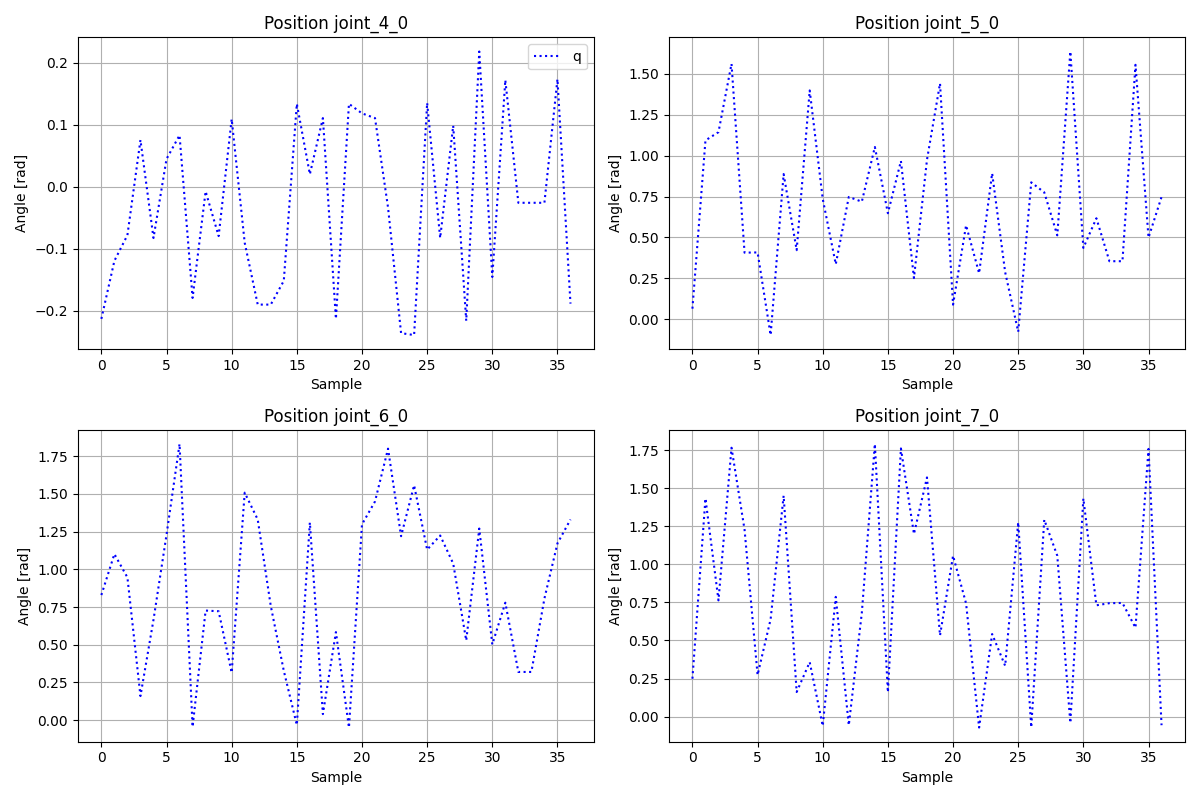

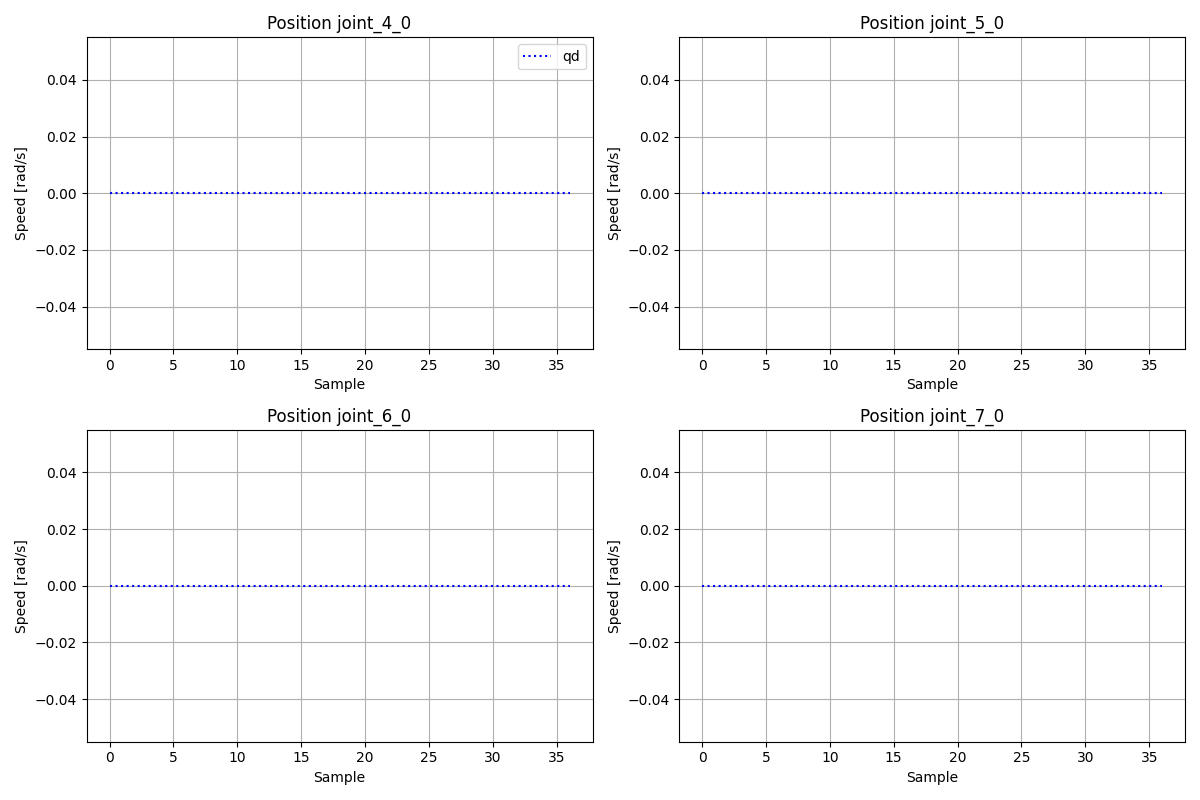

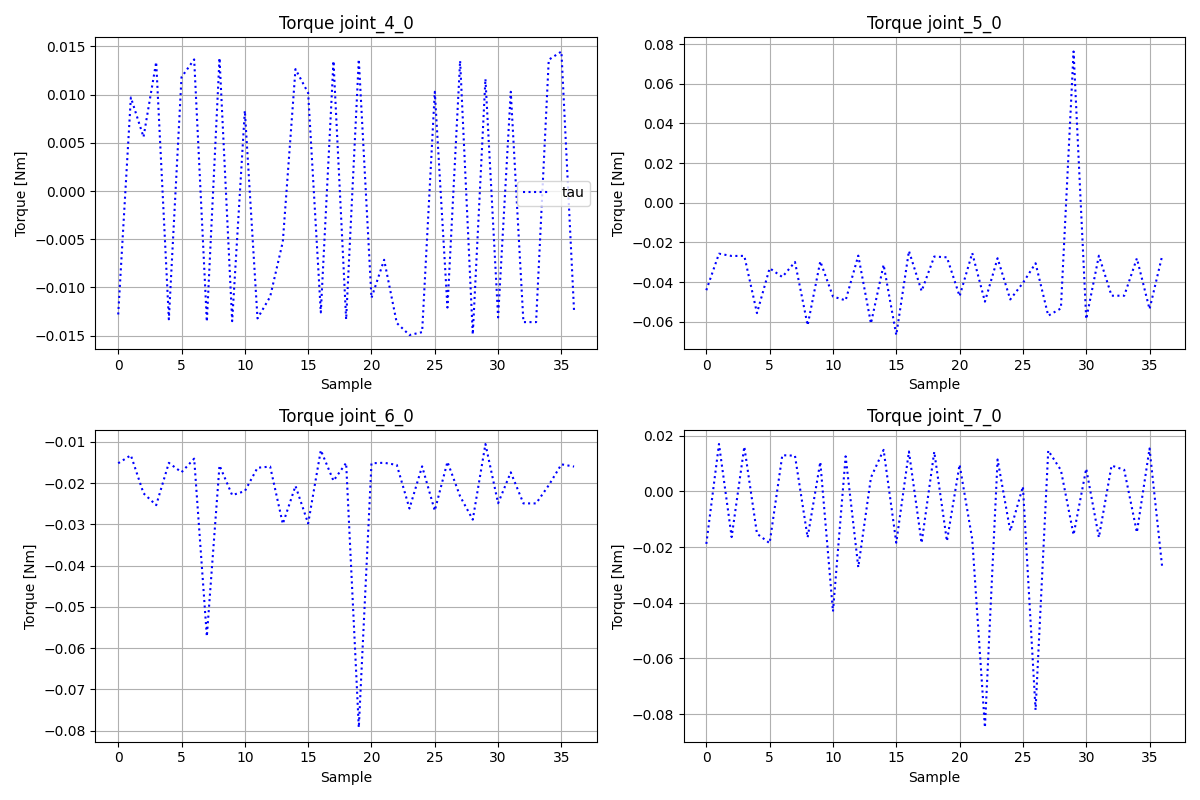

NameError: name 'delta_tau' is not defined

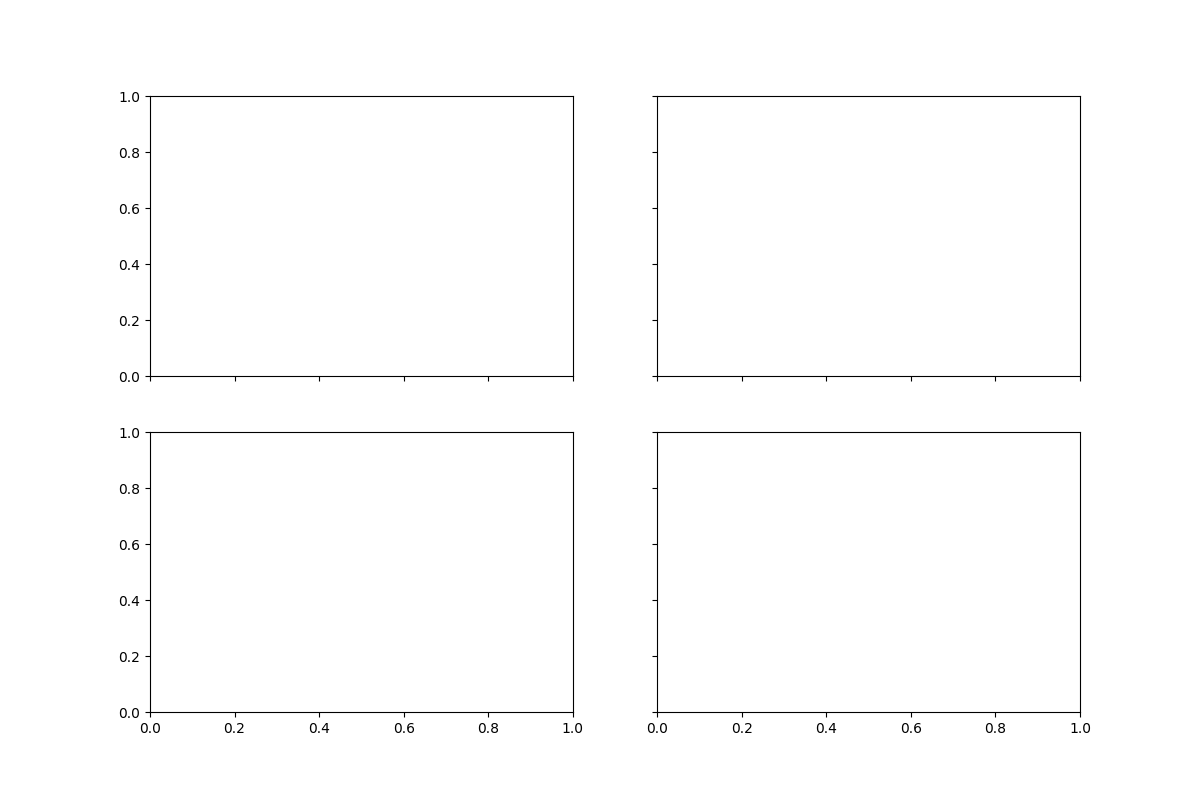

In [7]:
# =========================================================================================================================== Plot
# --- 1. Plot joint trajectories ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, q_log[:,i], 'b', linestyle='dotted', label='q')
    plt.xlabel('Sample')
    plt.ylabel('Angle [rad]')
    plt.title(f'Position {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, qd_log[:,i], 'b', linestyle='dotted', label='qd')
    plt.xlabel('Sample')
    plt.ylabel('Speed [rad/s]')
    plt.title(f'Position {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()

# --- 2. Plot joint tau ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, tau_log[:,i], 'b',linestyle='dotted', label = 'tau')
    #plt.plot(t_log, tau_log[:,i] + resid[i::4].flatten(), label = 'delta_tau')
    try:
        plt.plot(t_log, tau_log[:,i] - delta_tau[:,i], 'r', linestyle='dotted', label = 'hat_tau')
    except:
        pass
    plt.xlabel('Sample')
    plt.ylabel('Torque [Nm]')
    plt.title(f'Torque {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()

# --- 2. Plot Error tau ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
# Friction statica
static_frict_estim = np.array([[0.0120,-0.0120],
                               [0,0],
                               [0.0165,-0.0205],
                               [0.0140,-0.0150],])
for i, ax in enumerate(axes.flat):
    ax.scatter(t_log, delta_tau[:, i], color='b', label='delta_tau', s=8)
    ax.hlines(static_frict_estim[i,0], t_log[0], t_log[-1],
              colors='r', linestyles='dotted', linewidth=0.8)
    ax.hlines(static_frict_estim[i,1], t_log[0], t_log[-1],
              colors='r', linestyles='dotted', linewidth=0.8)

    ax.set_xlabel('Sample')
    ax.set_ylabel('Torque [Nm]')
    ax.set_title(f'Torque {JOINT_NAMES[i]}')
    ax.grid(True)

    if i == 0:
        ax.legend()
plt.tight_layout()
plt.show()
